In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5060 Ti


In [2]:
# Импорты и настройки
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import time

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Загрузка данных CIFAR-10
# Для ускорения возьмём подвыборку (первые 10000 обучающих, 2000 тестовых)
# Но можно и полный датасет, если есть время.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

train_full = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_full = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

# Для экспериментов возьмём подвыборку (ускорит обучение)
num_train = 10000
num_val = 2000
indices = torch.randperm(len(train_full))
train_indices = indices[:num_train]
val_indices = indices[num_train:num_train+num_val]

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(train_full, val_indices)
test_dataset = test_full

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

/home/alexprog/torch_env/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples: 10000
Val samples: 2000
Test samples: 10000


In [16]:
class MLP(nn.Module):
    def __init__(self, input_dim=3072, hidden_dims=[1024, 512, 256], output_dim=10, #hidden_dims=[512, 256, 128]
                 use_bn=False, dropout_rate=0.0, init_type='xavier'):
        super().__init__()
        self.use_bn = use_bn
        layers = []
        prev_dim = input_dim

        for i, h_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, h_dim))
            if use_bn:
                layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_dim = h_dim

        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

        self._initialize_weights(init_type)

    def _initialize_weights(self, init_type):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                
                if init_type == 'default':
                    continue
                elif init_type == 'zeros':
                    nn.init.zeros_(m.weight)
                elif init_type == 'normal':
                    nn.init.normal_(m.weight, mean=0, std=1)
                elif init_type == 'xavier':
                    nn.init.xavier_uniform_(m.weight)
                elif init_type == 'he':
                    nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (batch, 3, 32, 32) -> (batch, 3072)
        x = x.view(x.size(0), -1)
        return self.net(x)

In [17]:
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, patience=5, verbose=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_epoch = 0
    trigger_times = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Обучение
        model.train()
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
        train_loss /= len(train_loader.dataset)
        history['train_loss'].append(train_loss)

        # Валидация
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if verbose:
            print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            trigger_times = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    # Загружаем лучшую модель
    model.load_state_dict(torch.load('best_model.pth'))
    return model, history, best_epoch

In [7]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

init_types = ['default','zeros', 'normal', 'xavier', 'he']
histories = {}

for init in init_types:
    print(f'\n=== Инициализация: {init} ===')
    model = MLP(use_bn=False, dropout_rate=0.0, init_type=init).to(device)
    model, history, best_epoch = train_model(model, train_loader, val_loader, epochs=20, patience=5, verbose=False)
    histories[init] = history
    print(f'Best val acc: {max(history["val_acc"]):.4f}')

# Визуализация
fig = make_subplots(rows=1, cols=2, subplot_titles=('Train Loss', 'Val Accuracy'))
colors = {'default':'yellow','zeros':'black', 'normal':'red', 'xavier':'green', 'he':'blue'}
for init in init_types:
    fig.add_trace(go.Scatter(y=histories[init]['train_loss'], mode='lines', name=f'{init} train',
                              line=dict(color=colors[init], dash='dash')), row=1, col=1)
    fig.add_trace(go.Scatter(y=histories[init]['val_acc'], mode='lines', name=f'{init} val',
                              line=dict(color=colors[init])), row=1, col=2)
fig.update_xaxes(title_text='Epoch', row=1, col=1)
fig.update_xaxes(title_text='Epoch', row=1, col=2)
fig.update_yaxes(title_text='Loss', row=1, col=1)
fig.update_yaxes(title_text='Accuracy', row=1, col=2)
fig.show()


=== Инициализация: default ===
Early stopping at epoch 9
Best val acc: 0.4450

=== Инициализация: zeros ===
Early stopping at epoch 12
Best val acc: 0.1040

=== Инициализация: normal ===
Best val acc: 0.3005

=== Инициализация: xavier ===
Early stopping at epoch 8
Best val acc: 0.4345

=== Инициализация: he ===
Early stopping at epoch 8
Best val acc: 0.4135


In [8]:
histories_bn = {}
for use_bn in [False, True]:
    print(f'\n=== BatchNorm: {use_bn} ===')
    model = MLP(use_bn=use_bn, dropout_rate=0.0, init_type='he').to(device)
    model, history, _ = train_model(model, train_loader, val_loader, epochs=20, patience=5, verbose=False)
    histories_bn[use_bn] = history
    print(f'Best val acc: {max(history["val_acc"]):.4f}')

fig = make_subplots(rows=1, cols=2, subplot_titles=('Train Loss', 'Val Accuracy'))
fig.add_trace(go.Scatter(y=histories_bn[False]['train_loss'], mode='lines', name='без BN train', line=dict(dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(y=histories_bn[True]['train_loss'], mode='lines', name='с BN train', line=dict(dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(y=histories_bn[False]['val_acc'], mode='lines', name='без BN val'), row=1, col=2)
fig.add_trace(go.Scatter(y=histories_bn[True]['val_acc'], mode='lines', name='с BN val'), row=1, col=2)
fig.show()


=== BatchNorm: False ===
Early stopping at epoch 8
Best val acc: 0.4265

=== BatchNorm: True ===
Early stopping at epoch 9
Best val acc: 0.4485


In [9]:
dropout_rates = [0.0, 0.3, 0.5,0.6,0.75,1.0]
histories_drop = {}

for p in dropout_rates:
    print(f'\n=== Dropout p={p} ===')
    model = MLP(use_bn=True, dropout_rate=p, init_type='he').to(device)
    model, history, _ = train_model(model, train_loader, val_loader, epochs=20, patience=5, verbose=False)
    histories_drop[p] = history
    print(f'Best val acc: {max(history["val_acc"]):.4f}')

fig = go.Figure()
for p in dropout_rates:
    fig.add_trace(go.Scatter(y=histories_drop[p]['val_acc'], mode='lines', name=f'dropout {p}'))
fig.update_layout(title='Валидационная точность при разных Dropout', xaxis_title='Epoch', yaxis_title='Accuracy')
fig.show()


=== Dropout p=0.0 ===
Early stopping at epoch 8
Best val acc: 0.4500

=== Dropout p=0.3 ===
Early stopping at epoch 18
Best val acc: 0.4705

=== Dropout p=0.5 ===
Best val acc: 0.4615

=== Dropout p=0.6 ===
Best val acc: 0.4330

=== Dropout p=0.75 ===
Best val acc: 0.3655

=== Dropout p=1.0 ===
Early stopping at epoch 12
Best val acc: 0.0950


In [10]:
batch_sizes = [8,16,32,64,128,256]
histories_bs = {}

for bs in batch_sizes:
    print(f'\n=== Batch size = {bs} ===')
    train_loader_bs = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    val_loader_bs = DataLoader(val_dataset, batch_size=bs, shuffle=False)
    model = MLP(use_bn=True, dropout_rate=0.3, init_type='he').to(device)
    model, history, _ = train_model(model, train_loader_bs, val_loader_bs, epochs=20, patience=5, verbose=False)
    histories_bs[bs] = history
    print(f'Best val acc: {max(history["val_acc"]):.4f}')

fig = go.Figure()
for bs in batch_sizes:
    fig.add_trace(go.Scatter(y=histories_bs[bs]['val_acc'], mode='lines', name=f'batch {bs}'))
fig.update_layout(title='Валидационная точность при разном batch size', xaxis_title='Epoch', yaxis_title='Accuracy')
fig.show()


=== Batch size = 8 ===
Best val acc: 0.4515

=== Batch size = 16 ===
Best val acc: 0.4705

=== Batch size = 32 ===
Early stopping at epoch 18
Best val acc: 0.4665

=== Batch size = 64 ===
Early stopping at epoch 17
Best val acc: 0.4730

=== Batch size = 128 ===
Early stopping at epoch 17
Best val acc: 0.4705

=== Batch size = 256 ===
Best val acc: 0.4690


In [19]:
# Определим трансформацию с аугментацией
transform_train = transforms.Compose([
    #transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),  # случайное отражение
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

# Создадим датасеты с новой трансформацией
train_aug = datasets.CIFAR10('./data', train=True, download=True, transform=transform_train)
val_aug = datasets.CIFAR10('./data', train=True, download=True, transform=transform_val)

# Используем те же индексы подвыборки
train_aug_sub = Subset(train_aug, train_indices)
val_aug_sub = Subset(val_aug, val_indices)

train_loader_aug = DataLoader(train_aug_sub, batch_size=64, shuffle=True)
val_loader_aug = DataLoader(val_aug_sub, batch_size=64, shuffle=False)

# Обучим модель с аугментацией
model_aug = MLP(use_bn=True, dropout_rate=0.3, init_type='he').to(device)
model_aug, history_aug, _ = train_model(model_aug, train_loader_aug, val_loader_aug, epochs=20, patience=5, verbose=False)
print(f'Best val acc with augmentation: {max(history_aug["val_acc"]):.4f}')

# Для сравнения возьмём историю без аугментации (из предыдущего эксперимента с bs=64, dropout=0.3)
history_no_aug = histories_drop[0.3]  # но там bs=64, BN=True? Да, в histories_drop для p=0.3 мы использовали BN и batch 64.

fig = go.Figure()
fig.add_trace(go.Scatter(y=history_no_aug['val_acc'], mode='lines', name='без аугментации'))
fig.add_trace(go.Scatter(y=history_aug['val_acc'], mode='lines', name='с аугментацией'))
fig.update_layout(title='Влияние аугментации (горизонтальное отражение)', xaxis_title='Epoch', yaxis_title='Accuracy')
fig.show()

Best val acc with augmentation: 0.4905


In [21]:
best_model = MLP(use_bn=True, dropout_rate=0.3, init_type='default').to(device)
best_model, history_best, best_epoch = train_model(best_model, train_loader_aug, val_loader_aug,
                                                    epochs=80, lr=0.0005, patience=7, verbose=True)

print(f'\nОбучение остановлено на эпохе {best_epoch+1} с лучшей валидационной точностью: {max(history_best["val_acc"]):.4f}')

# Финальное тестирование
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
best_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = best_model(inputs)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
test_acc = correct / total
print(f'Test accuracy: {test_acc:.4f}')

Epoch 1/80 | Train Loss: 1.9668 | Val Loss: 1.7487 | Val Acc: 0.3685
Epoch 2/80 | Train Loss: 1.7872 | Val Loss: 1.7017 | Val Acc: 0.3995
Epoch 3/80 | Train Loss: 1.7067 | Val Loss: 1.6532 | Val Acc: 0.4085
Epoch 4/80 | Train Loss: 1.6679 | Val Loss: 1.6318 | Val Acc: 0.4195
Epoch 5/80 | Train Loss: 1.6116 | Val Loss: 1.5992 | Val Acc: 0.4295
Epoch 6/80 | Train Loss: 1.5739 | Val Loss: 1.5588 | Val Acc: 0.4455
Epoch 7/80 | Train Loss: 1.5415 | Val Loss: 1.5396 | Val Acc: 0.4510
Epoch 8/80 | Train Loss: 1.5304 | Val Loss: 1.5345 | Val Acc: 0.4575
Epoch 9/80 | Train Loss: 1.5045 | Val Loss: 1.5024 | Val Acc: 0.4550
Epoch 10/80 | Train Loss: 1.4736 | Val Loss: 1.5018 | Val Acc: 0.4640
Epoch 11/80 | Train Loss: 1.4546 | Val Loss: 1.5024 | Val Acc: 0.4590
Epoch 12/80 | Train Loss: 1.4310 | Val Loss: 1.4757 | Val Acc: 0.4705
Epoch 13/80 | Train Loss: 1.4188 | Val Loss: 1.4843 | Val Acc: 0.4605
Epoch 14/80 | Train Loss: 1.4065 | Val Loss: 1.4522 | Val Acc: 0.4790
Epoch 15/80 | Train Loss: 1.3

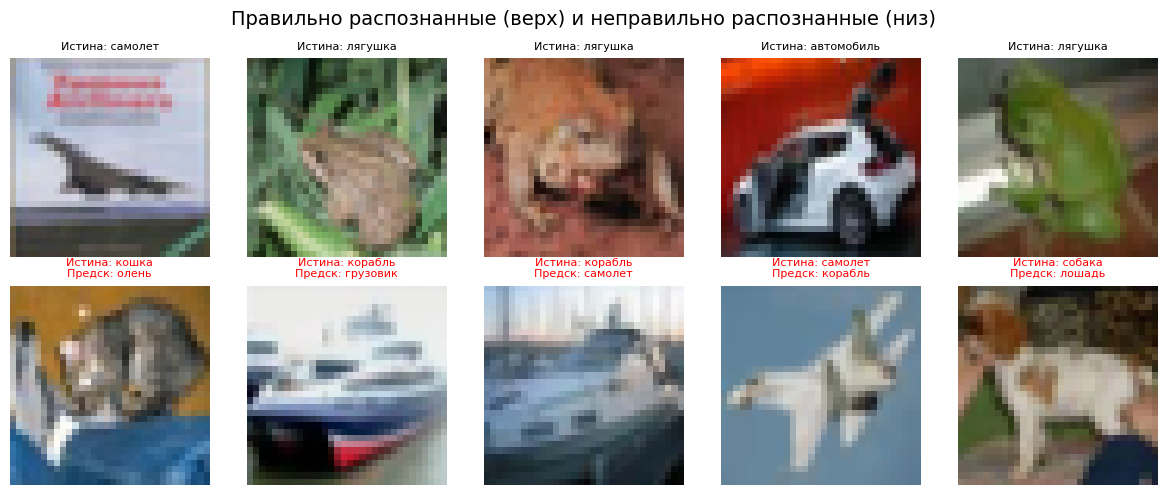

In [22]:
# Функция для денормализации изображения
def denormalize(img_tensor):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.247, 0.243, 0.261])
    img = img_tensor.numpy().transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

# Функция для отображения примеров правильных и неправильных предсказаний
def show_predictions(model, test_loader, class_names, device, num_examples=5):
    model.eval()
    correct_examples = []
    wrong_examples = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                if preds[i] == labels[i]:
                    if len(correct_examples) < num_examples:
                        correct_examples.append((images[i].cpu(), labels[i].cpu(), preds[i].cpu()))
                else:
                    if len(wrong_examples) < num_examples:
                        wrong_examples.append((images[i].cpu(), labels[i].cpu(), preds[i].cpu()))

            if len(correct_examples) >= num_examples and len(wrong_examples) >= num_examples:
                break

    # Отображение
    fig, axes = plt.subplots(2, num_examples, figsize=(12, 5))
    fig.suptitle('Правильно распознанные (верх) и неправильно распознанные (низ)', fontsize=14)

    for i in range(num_examples):
        # Правильные
        img, label, pred = correct_examples[i]
        ax = axes[0, i]
        ax.imshow(denormalize(img))
        ax.set_title(f'Истина: {class_names[label]}', fontsize=8)
        ax.axis('off')

        # Неправильные
        img, label, pred = wrong_examples[i]
        ax = axes[1, i]
        ax.imshow(denormalize(img))
        ax.set_title(f'Истина: {class_names[label]}\nПредск: {class_names[pred]}', fontsize=8, color='red')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Пример использования:
class_names = ['самолет', 'автомобиль', 'птица', 'кошка', 'олень', 'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
show_predictions(best_model, test_loader, class_names, device, num_examples=5)